# Taller: Modelos de Regresión - Predicción de Precios de Autos Usados


In [ ]:
# se importan las librerías necesarias para el análisis de datos, visualización y modelado predictivo.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se importan las librerías necesarias para la preparación de datos y evaluación de modelos.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Modelos de regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


## 1. Carga de Datos y Análisis Exploratorio Inicial

In [ ]:
# Cargar el conjunto de datos
df = pd.read_csv("cardekho.csv")
df.head()


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [ ]:
# Información general del DataFrame
df.info()
# Estadísticas descriptivas del DataFrame
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   str    
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   str    
 5   seller_type         8128 non-null   str    
 6   transmission        8128 non-null   str    
 7   owner               8128 non-null   str    
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   str    
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), str(6)
memory usage: 762.1 KB


,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [ ]:
# Verificar valores nulos en el DataFrame
df.isnull().sum()

name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             215
seats                 221
dtype: int64

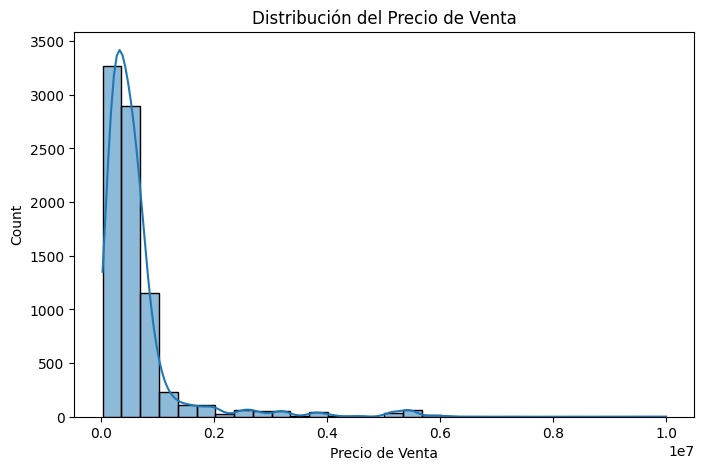

In [29]:
# Visualización de la distribución del precio de venta 
plt.figure(figsize=(8,5))
sns.histplot(df["selling_price"], bins=30, kde=True)
plt.title("Distribución del Precio de Venta")
plt.xlabel("Precio de Venta")
plt.show()

## 2. Preprocesamiento de Datos e Ingeniería de Características

In [ ]:
# Preparación de datos Eliminación de la columna "name" ya que no es relevante para el análisis y modelado.
df = df.drop("name", axis=1)

In [ ]:
# Mapeo de la columna "owner" a valores numéricos Definimos un diccionario para mapear los valores de la columna "owner" a valores numéricos. 
# Esto es útil para convertir variables categóricas en un formato que pueda ser utilizado por los modelos de machine learning.
owner_map = {
    'First Owner':1,
    'Second Owner':2,
    'Third Owner':3,
    'Fourth & Above Owner':4,
    'Test Drive Car':0
}
df["owner"] = df["owner"].map(owner_map)

In [ ]:
# Limpieza de la columna "max_power" para extraer solo los valores numéricos.
# cada valor de la columna "max_power" se encuentra en formato de texto y puede contener unidades o caracteres adicionales.
df["max_power"] = df["max_power"].str.extract(r'(\d+\.?\d*)')
# Convertimos la columna "max_power" a tipo float para su análisis y modelado.
df["max_power"] = df["max_power"].astype(float)


In [ ]:
# Verificar valores nulos en el DataFrame
df.isnull().sum()

year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                   0
mileage(km/ltr/kg)    221
engine                221
max_power             216
seats                 221
dtype: int64

In [ ]:
# Eliminación de filas con valores nulos en el DataFrame para asegurar que los modelos de machine learning no se vean afectados por datos faltantes.
df = df.dropna()

In [ ]:
# Codificación de variables categóricas utilizando one-hot encoding. 
# Esto convierte las columnas categóricas en columnas binarias (0 o 1) para que puedan ser utilizadas por los modelos de machine learning. 
# Como son la fuel , seller_type y transmission. se utiliza drop_first=True para evitar la multicolinealidad.
df = pd.get_dummies(
    df,
    columns=["fuel", "seller_type", "transmission"],
    drop_first=True
)

#### Escalado de los datos

In [ ]:
# Separación de las características (X) y la variable objetivo (y). 
# Separamos la columna "selling_price" como variable objetivo y el resto de las columnas como características.
X = df.drop("selling_price", axis=1)

y = df["selling_price"]

In [ ]:
# Escalado de características utilizando StandardScaler. 
# Definimos un objeto StandardScaler y lo utilizamos para ajustar y transformar las características (X) para que tengan media 0 y desviación estándar 1. Esto es importante para muchos algoritmos de machine learning que son sensibles a la escala de los datos.
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 3. División del Dataset

In [ ]:
# División del conjunto de datos en entrenamiento y prueba.
# Separamos el 80% de los datos para entrenamiento y el 20% restante para prueba. 
# Esto nos permite evaluar el rendimiento de los modelos en datos no vistos durante el entrenamiento.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)


## 4. Entrenamiento de Modelos

In [ ]:
# Entrenamiento del modelo de regresión lineal. 
# Proporciona una línea de mejor ajuste para los datos, minimizando la suma de los errores al cuadrado.
modelo1 = LinearRegression()

modelo1.fit(X_train, y_train)

pred1 = modelo1.predict(X_test)

In [ ]:
# Entrenamiento del modelo de árbol de decisión. 
# Proporciona un modelo no lineal que puede capturar relaciones complejas en los datos dividiendo el espacio de características en regiones basadas en decisiones binarias.
modelo2 = DecisionTreeRegressor(random_state=42)

modelo2.fit(X_train, y_train)

pred2 = modelo2.predict(X_test)

In [ ]:
# Entrenamiento del modelo de bosque aleatorio.
# Combina múltiples árboles de decisión para mejorar la precisión y reducir el sobreajuste.
modelo3 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo3.fit(X_train, y_train)

pred3 = modelo3.predict(X_test)

## 5. Evaluación y Comparación de Resultados

In [ ]:
# Evaluación de los modelos utilizando la métrica R^2 (coeficiente de determinación).
# la metrica R^2 indica qué tan bien los modelos explican la variabilidad de los datos de prueba. 
# Un valor más cercano a 1 indica un mejor ajuste del modelo a los datos.
r2_1 = r2_score(y_test, pred1)
r2_2 = r2_score(y_test, pred2)
r2_3 = r2_score(y_test, pred3)

print("Regresión Lineal:", r2_1)
print("Árbol:", r2_2)
print("Random Forest:", r2_3)

Regresión Lineal: 0.6950234510153064
Árbol: 0.9652488294846462
Random Forest: 0.9836840390844271


In [ ]:
# Evaluación de los modelos utilizando la métrica MSE (Error Cuadrático Medio).
# La métrica MSE indica el promedio de los errores al cuadrado entre las predicciones
mse1 = mean_squared_error(y_test, pred1)
mse2 = mean_squared_error(y_test, pred2)
mse3 = mean_squared_error(y_test, pred3)

print("MSE Lineal:", mse1)
print("MSE Árbol:", mse2)
print("MSE Random Forest:", mse3)

MSE Lineal: 212045022273.25143
MSE Árbol: 24161899498.441723
MSE Random Forest: 11344210914.806414


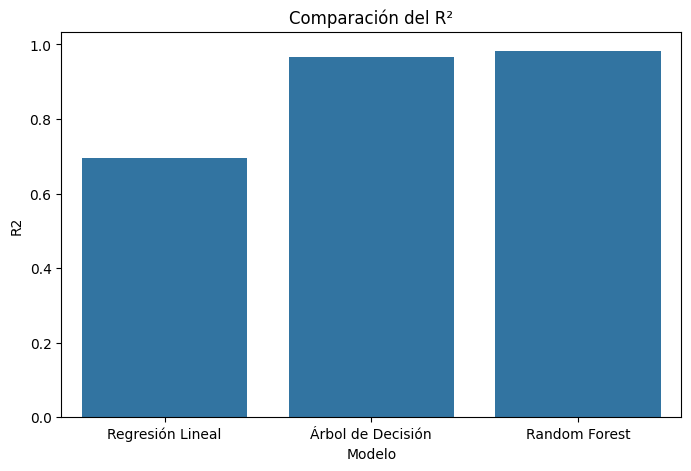

In [ ]:
# Comparación de los resultados de R² entre los modelos utilizando un gráfico de barras.
# finalmente, se crea un DataFrame con los resultados de R² para cada modelo y se visualiza utilizando un gráfico de barras para comparar el rendimiento de los modelos.
resultados = pd.DataFrame({
    "Modelo":[
        "Regresión Lineal",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "R2":[r2_1,r2_2,r2_3]
})

plt.figure(figsize=(8,5))

sns.barplot(
    data=resultados,
    x="Modelo",
    y="R2"
)

plt.title("Comparación del R²")
plt.show()

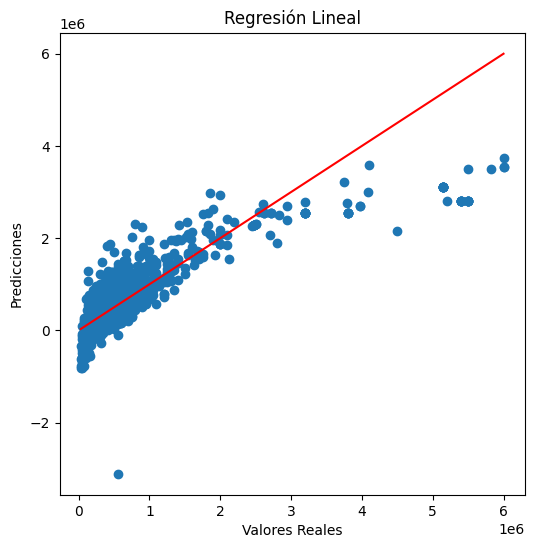

In [ ]:
# Visualización de las predicciones del modelo de regresión lineal frente a los valores reales.
# El gráfico de dispersión muestra la relación entre los valores reales y las predicciones del modelo de regresión lineal.
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred1)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal")
plt.show()

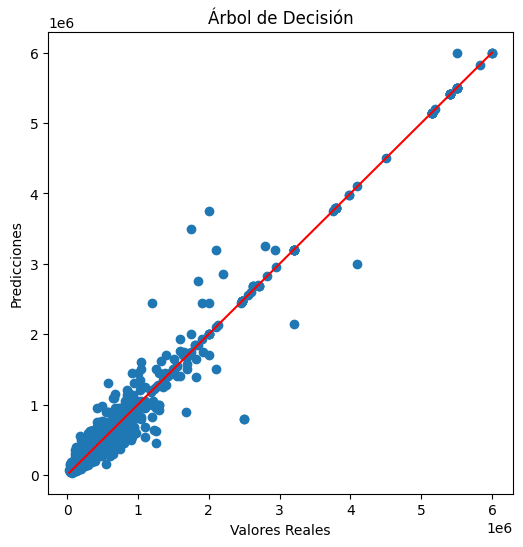

In [ ]:
# Visualización de las predicciones del modelo de árbol de decisión frente a los valores reales.
# El gráfico de dispersión muestra la relación entre los valores reales y las predicciones del modelo de árbol de decisión.
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred2)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Árbol de Decisión")
plt.show()

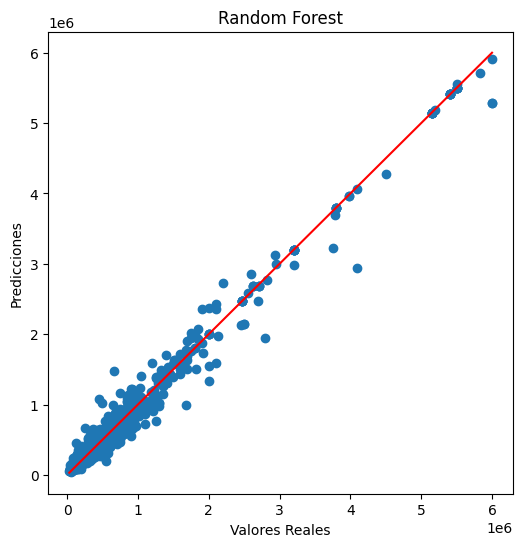

In [ ]:
# Visualización de las predicciones del modelo de random forest frente a los valores reales.
# El gráfico de dispersión muestra la relación entre los valores reales y las predicciones del modelo de random forest.
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Random Forest")
plt.show()

Primero realizamos un análisis exploratorio para conocer la estructura del conjunto de datos y detectar posibles valores nulos. Luego preprocesamos la información eliminando columnas poco útiles, convirtiendo variables categóricas en numéricas mediante codificación ordinal y One-Hot Encoding, y limpiando columnas que contenían texto junto con valores numéricos. Después escalamos las variables y dividimos el conjunto de datos en entrenamiento y prueba. A continuación entrenamos tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest. Finalmente evaluamos su desempeño utilizando las métricas R² y MSE, además de gráficas de comparación y de valores reales frente a predichos. El modelo con el mayor R², el menor MSE y cuyos puntos quedaron más cercanos a la línea diagonal en la gráfica de dispersión fue el que ofreció las mejores predicciones del precio de los vehículos.

Escogería el modelo Random Forest, ya que obtuvo el mayor coeficiente de determinación (R² = 0.9837), lo que significa que explica aproximadamente el 98.4% de la variación en los precios de los vehículos. Además, presentó el menor Error Cuadrático Medio (MSE = 11,344,210,914), indicando que sus predicciones son las más cercanas a los valores reales. Estos resultados también se reflejan en la gráfica de valores reales versus predichos, donde los puntos se encuentran más próximos a la línea diagonal de referencia, evidenciando una mayor precisión del modelo.
